# Which Neighborhoods Are Transit-Privileged?

We compare **official Boston neighborhood polygons** (Analyze Boston / BPDA) to **MBTA rapid transit** (subway + trolley types 0 and 1) and a **real-time disruption exposure** index derived from active **service alerts**.

## What “transit privilege” means here (operational definition)

- **Access** — how many **distinct rapid-transit stops** fall inside a neighborhood, normalized by land area (**stops per km²**). More nearby rapid transit generally means less walk/wait friction for core radial trips.
- **Disruption exposure (delay proxy)** — a **snapshot** sum of **MBTA alert severities** (0–10) for distinct alerts whose `informed_entity` references a route or stop that touches the neighborhood. This measures **how much official disruption messaging is aimed at riders in that area right now**, not chronic schedule adherence over months.
- **Composite “privilege” score** — z-scored access minus z-scored **live alert** exposure and half of z-scored **MassDOT chronic pain** (Blue Book wait-time ratios by route) so that **high is “better”**. See the scoring cell for the `privilege_z_alerts_only` comparison. This is an exploratory index, not a moral claim about residents.

## Ethics + limitations

- “Privilege” here is **structural service advantage** in the MBTA + BPDA map sense, **not** individual wealth or worth.
- The MBTA JSON API is **rate-limited** (~20 requests/minute without an API key). This notebook spaces calls and only pulls **rapid transit** plus **alerts** to stay polite.
- **Alerts ≠ average lateness.** They skew toward unusual events; some chronic delays never become alerts. A small **schedule vs prediction** demo at Harvard Sq illustrates one “minutes late” snapshot, not system-wide OTP.
- Results are **time-stamped**: re-run the notebook on a different day and rankings will move.

**Data:** [BPDA neighborhood boundaries GeoJSON](https://data.boston.gov/dataset/bpda-neighborhood-boundaries) · [MBTA V3 API](https://www.mbta.com/developers/v3-api) · [MBTA Blue Book / MassDOT reliability (ArcGIS)](https://mbta-massdot.opendata.arcgis.com/)

In [1]:
import io
import json
import time
import urllib.error
import urllib.parse
import urllib.request
from collections import defaultdict
from datetime import datetime, timezone
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
UA = {'User-Agent': 'cursor-boston-pydata-2026-notebook/1.0 (+https://cursorboston.com)'}
REQUEST_PAUSE_S = 3.2
# --- politeness + reproducibility ---

def mbta_request(path: str, params: dict | None=None) -> dict:  # stay under ~20 MBTA requests/minute without an API key
    q = urllib.parse.urlencode(params or {}, doseq=True)
    url = f'https://api-v3.mbta.com/{path}?{q}' if q else f'https://api-v3.mbta.com/{path}'
    req = urllib.request.Request(url, headers=UA)
    time.sleep(REQUEST_PAUSE_S)
    with urllib.request.urlopen(req, timeout=120) as resp:
        return json.load(resp)

def fetch_all_mbta(path: str, base_params: dict) -> list[dict]:
    out: list[dict] = []
    params = dict(base_params)
    while True:
        page = mbta_request(path, params)
        out.extend(page.get('data', []))
        nxt = (page.get('links') or {}).get('next')
        if not nxt:
            break
        qs = urllib.parse.urlparse(nxt).query
        params = dict(urllib.parse.parse_qsl(qs))
    return out
print('Run timestamp (UTC):', datetime.now(timezone.utc).isoformat(timespec='seconds'))

Run timestamp (UTC): 2026-05-14T00:41:11+00:00


## 1) Neighborhood boundaries (Boston)

We download the BPDA GeoJSON via `requests` (Analyze Boston sometimes rejects bare `urllib` clients with **403**). CRS is WGS84; we also project to **EPSG:32619** (UTM zone 19N) for area in km².

In [2]:
NB_URL = (
    "https://data.boston.gov/dataset/bf1a7b50-4c72-4637-b0fa-11d632e3aff1/resource/"
    "e5849875-a6f6-4c9c-9d8a-5048b0fbd03e/download/boston_neighborhood_boundaries.geojson"
)

r = requests.get(NB_URL, headers=UA, timeout=120)
r.raise_for_status()
nb = gpd.read_file(io.BytesIO(r.content))
assert "name" in nb.columns
nb = nb[["name", "geometry"]].copy()
nb = nb.rename(columns={"name": "neighborhood"})
nb = nb.to_crs(4326)

# Project for area
nb_utm = nb.to_crs(32619)
nb_utm["area_km2"] = nb_utm.geometry.area / 1e6
area_lookup = nb_utm.set_index("neighborhood")["area_km2"]
nb["area_km2"] = nb["neighborhood"].map(area_lookup)

nb.head()

,neighborhood,geometry,area_km2
0,Roslindale,"MULTIPOLYGON (((-71.12593 42.272, -71.12611 42...",6.497670
1,Jamaica Plain,"POLYGON ((-71.10499 42.32609, -71.10503 42.326...",10.195180
2,Mission Hill,"POLYGON ((-71.09043 42.33576, -71.0905 42.3357...",1.419860
3,Longwood,"POLYGON ((-71.09811 42.33672, -71.09832 42.337...",0.763289
4,Bay Village,"POLYGON ((-71.06663 42.34877, -71.06663 42.348...",0.107401


## 2) Rapid-transit stops (MBTA types 0 + 1)

The V3 API does not return related `route` objects on `/stops` the way we need for a single query, so we list **routes with `filter[type]=0` and `1`**, then pull `/stops?filter[route]=…` for each and **deduplicate** by stop id (Green Line branches reuse many of the same platforms).

In [3]:
rapid_routes: list[tuple[str, int]] = []
for rtype in (0, 1):
    chunk = mbta_request('routes', {'filter[type]': str(rtype), 'fields[route]': 'short_name,type'})
    for _row in chunk['data']:
        rapid_routes.append((_row['id'], int(_row['attributes']['type'])))
print('Rapid routes:', [x[0] for x in rapid_routes])
stop_rows: dict[str, dict] = {}
for route_id, route_type in rapid_routes:
    stops = fetch_all_mbta('stops', {'filter[route]': route_id, 'fields[stop]': 'latitude,longitude,name,municipality,location_type'})
    for s in stops:
        sid = s['id']
        lat = s['attributes'].get('latitude')
        lon = s['attributes'].get('longitude')
        if lat is None or lon is None:
            continue
        if sid not in stop_rows:
            stop_rows[sid] = {'stop_id': sid, 'stop_name': s['attributes'].get('name'), 'latitude': float(lat), 'longitude': float(lon), 'municipality': s['attributes'].get('municipality'), 'routes': {route_id}, 'route_types': {route_type}}
        else:
            stop_rows[sid]['routes'].add(route_id)
            stop_rows[sid]['route_types'].add(route_type)
stops_df = pd.DataFrame([{'stop_id': v['stop_id'], 'stop_name': v['stop_name'], 'latitude': v['latitude'], 'longitude': v['longitude'], 'municipality': v['municipality'], 'routes': sorted(v['routes']), 'route_types': sorted(v['route_types'])} for v in stop_rows.values()])
stops_gdf = gpd.GeoDataFrame(stops_df, geometry=gpd.points_from_xy(stops_df['longitude'], stops_df['latitude'], crs='EPSG:4326'))
print('Distinct rapid-transit parent stops:', len(stops_gdf))
stops_gdf.head()

Rapid routes: ['Mattapan', 'Green-B', 'Green-C', 'Green-D', 'Green-E', 'Red', 'Orange', 'Blue']


Distinct rapid-transit parent stops: 125


,stop_id,stop_name,latitude,longitude,municipality,routes,route_types,geometry
0,place-asmnl,Ashmont,42.284520,-71.063777,Boston,"[Mattapan, Red]","[0, 1]",POINT (-71.06378 42.28452)
1,place-cedgr,Cedar Grove,42.279629,-71.060394,Boston,[Mattapan],[0],POINT (-71.06039 42.27963)
2,place-butlr,Butler,42.272429,-71.062519,Boston,[Mattapan],[0],POINT (-71.06252 42.27243)
3,place-miltt,Milton,42.270349,-71.067266,Milton,[Mattapan],[0],POINT (-71.06727 42.27035)
4,place-cenav,Central Avenue,42.270027,-71.073444,Milton,[Mattapan],[0],POINT (-71.07344 42.27003)


## 3) Spatial join — stops ↔ neighborhoods

We keep only stops **inside** a neighborhood polygon (inner join). That drops Cambridge/Brookline/etc. stops outside the BPDA Boston footprint — a geographic scope choice, not a value judgment about those places.

In [4]:
joined = gpd.sjoin(stops_gdf, nb[['neighborhood', 'geometry', 'area_km2']], predicate='within', how='inner')
access = joined.groupby('neighborhood').agg(rapid_stops=('stop_id', 'nunique'), area_km2=('area_km2', 'first')).reset_index()
access['rapid_stops_per_km2'] = access['rapid_stops'] / access['area_km2']
stop_to_neighborhood = joined.set_index('stop_id')['neighborhood'].to_dict()
route_to_neighborhoods: dict[str, set[str]] = defaultdict(set)
for _, _row in joined.iterrows():
    for rid in _row['routes']:
        route_to_neighborhoods[str(rid)].add(_row['neighborhood'])
access.sort_values('rapid_stops_per_km2', ascending=False).head(8)

,neighborhood,rapid_stops,area_km2,rapid_stops_per_km2
6,Downtown,9,1.608468,5.595387
15,West End,3,0.770869,3.891711
8,Fenway,8,2.268738,3.526189
12,Mission Hill,5,1.419860,3.521474
1,Back Bay,5,1.615947,3.094161
10,Longwood,2,0.763289,2.620238
2,Beacon Hill,2,0.809988,2.469173
0,Allston,6,4.041004,1.484779


## 3b) Chronic reliability — MassDOT “Blue Book” open data

To complement the **real-time alert snapshot**, we pull published reliability counts from the ArcGIS layer
[*MBTA Bus, Commuter Rail, & Rapid Transit Reliability*](https://mbta-massdot.opendata.arcgis.com/datasets/massdot::mbta-bus-commuter-rail-rapid-transit-reliability/about)
(same catalog as the [MBTA Blue Book Open Data Portal](https://mbta-massdot.opendata.arcgis.com/)).

In this layer, **`Headway / Schedule Adherence` rows are published for bus routes**; for **`mode_type = 'Rail'`** the portal exposes **`Passenger Wait Time`** rows with the same `otp_numerator` / `otp_denominator` fields. We aggregate those ratios **by `gtfs_route_id` over the most recent ~12 weeks in the extract**, then average across the rapid-transit routes touching each neighborhood’s stops. **Pain** = `1 − ratio` (higher means worse published performance on that metric). Compare cautiously to the Harvard prediction-gap demo — different definitions, same theme.


In [5]:
REL_QUERY = (
    "https://services1.arcgis.com/ceiitspzDAHrdGO1/arcgis/rest/services/"
    "MBTA_Rail_and_Bus_Reliability/FeatureServer/0/query"
)
rel_params = {
    "where": "mode_type = 'Rail' AND metric_type = 'Passenger Wait Time'",
    "outFields": "service_date,gtfs_route_id,otp_numerator,otp_denominator",
    "returnGeometry": "false",
    "orderByFields": "service_date DESC",
    "resultRecordCount": "2000",
    "f": "json",
}
rr = requests.get(REL_QUERY, params=rel_params, headers=UA, timeout=120)
rr.raise_for_status()
rel = rr.json()
rel_rows = [f["attributes"] for f in rel.get("features", [])]
rel_df = pd.DataFrame(rel_rows)
if rel_df.empty:
    raise RuntimeError("Blue Book reliability query returned no rows — check portal status.")
rel_df["service_date"] = pd.to_datetime(rel_df["service_date"], unit="ms", utc=True)
cutoff = rel_df["service_date"].max() - pd.Timedelta(days=7 * 12)
rel_recent = rel_df[rel_df["service_date"] >= cutoff]
grp = rel_recent.groupby("gtfs_route_id", as_index=True)[["otp_numerator", "otp_denominator"]].sum()
otp_by_route = (grp["otp_numerator"] / grp["otp_denominator"]).rename("route_adherence")

def _stop_adherence(routes: list[str]) -> float:
    vals = [float(otp_by_route.loc[r]) for r in routes if r in otp_by_route.index]
    if not vals:
        return float("nan")
    return float(np.mean(vals))

_js = joined.assign(bb_stop_adherence=joined["routes"].apply(_stop_adherence))
chronic = _js.groupby("neighborhood", as_index=False)["bb_stop_adherence"].mean()
chronic = chronic.rename(columns={"bb_stop_adherence": "route_adherence"})
chronic["chronic_pain"] = 1.0 - chronic["route_adherence"]
med_pain = float(np.nanmedian(chronic["chronic_pain"]))
chronic["chronic_pain"] = chronic["chronic_pain"].fillna(med_pain)
chronic.sort_values("route_adherence", ascending=False).head(8)


,neighborhood,route_adherence,chronic_pain
4,Charlestown,0.944378,0.055622
13,Roxbury,0.944378,0.055622
7,East Boston,0.938597,0.061403
9,Jamaica Plain,0.915541,0.084459
6,Downtown,0.910693,0.089307
5,Dorchester,0.907845,0.092155
14,South Boston,0.907845,0.092155
15,West End,0.844533,0.155467


## 4) Disruption exposure from active alerts

We page through `/alerts`, keep `lifecycle` in **`NEW`** or **`ONGOING`**, parse each `informed_entity`, and attribute **severity** (fallback 1) to every neighborhood touched by referenced routes or stops.

In [6]:
alerts = fetch_all_mbta("alerts", {"fields[alert]": "header,informed_entity,lifecycle,severity"})

active = [
    a
    for a in alerts
    if a.get("attributes", {}).get("lifecycle") in {"NEW", "ONGOING"}
]
print("Total alerts:", len(alerts), "active NEW/ONGOING:", len(active))

nb_exposure = defaultdict(float)
nb_alert_hits = defaultdict(int)

for a in active:
    sev = float(a["attributes"].get("severity") or 1)
    touched: set[str] = set()
    for ent in a["attributes"].get("informed_entity") or []:
        if isinstance(ent, dict) and ent.get("route"):
            touched |= route_to_neighborhoods.get(str(ent["route"]), set())
        if isinstance(ent, dict) and ent.get("stop"):
            nhood = stop_to_neighborhood.get(str(ent["stop"]))
            if nhood:
                touched.add(nhood)
    for nhood in touched:
        nb_exposure[nhood] += sev
        nb_alert_hits[nhood] += 1

if nb_exposure:
    exposure_df = pd.DataFrame(
        {
            "neighborhood": sorted(nb_exposure.keys()),
            "alert_severity_sum": [nb_exposure[n] for n in sorted(nb_exposure.keys())],
            "alert_count": [nb_alert_hits[n] for n in sorted(nb_exposure.keys())],
        }
    )
else:
    exposure_df = pd.DataFrame(columns=["neighborhood", "alert_severity_sum", "alert_count"])
exposure_df.sort_values("alert_severity_sum", ascending=False).head(8) if len(exposure_df) else exposure_df

Total alerts: 121 active NEW/ONGOING: 80


,neighborhood,alert_severity_sum,alert_count
5,Downtown,39.0,17
12,Roxbury,36.0,10
14,West End,35.0,16
1,Beacon Hill,31.0,11
4,Dorchester,26.0,10
13,South Boston,23.0,9
0,Back Bay,19.0,9
3,Charlestown,8.0,6


## 5) Optional “minutes late” snapshot (Harvard Sq)

Three `predictions` with `include=schedule` illustrate **prediction delay** (not OTP). If a schedule link is missing, we skip that row.

In [7]:
def _parse_iso(ts: str | None) -> pd.Timestamp | None:
    if not ts:
        return None
    return pd.to_datetime(ts, utc=True)


pred_page = mbta_request(
    "predictions",
    {
        "filter[stop]": "place-harsq",
        "page[limit]": "5",
        "include": "schedule",
    },
)
included = {f"{x['type']}:{x['id']}": x for x in pred_page.get("included", [])}
rows = []
for p in pred_page.get("data", []):
    sch = p.get("relationships", {}).get("schedule", {}).get("data")
    if not sch:
        continue
    sch_obj = included.get(f"{sch['type']}:{sch['id']}")
    if not sch_obj:
        continue
    p_dep = _parse_iso(p["attributes"].get("departure_time") or p["attributes"].get("arrival_time"))
    s_dep = _parse_iso(
        sch_obj["attributes"].get("departure_time") or sch_obj["attributes"].get("arrival_time")
    )
    if p_dep is None or s_dep is None:
        continue
    rows.append((p_dep - s_dep).total_seconds() / 60.0)

demo = pd.DataFrame({"prediction_delay_minutes": rows}) if rows else pd.DataFrame({"prediction_delay_minutes": []})
demo.describe().T if len(demo) else demo

,count,mean,std,min,25%,50%,75%,max
prediction_delay_minutes,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6) Composite score + sensitivity to “rail-only” weighting

We z-score **log1p(rapid stops per km²)** for access (`za`), z-score **alert severity exposure** (`zd`), and z-score **Blue Book chronic pain** (`zb` = worse published wait-time ratios). The headline **`privilege_z`** subtracts **both** disruption channels with a 50/50 blend on the chronic term: `za - zd - 0.5 * zb`. **`privilege_z_alerts_only`** keeps the original alerts-only index for comparison. **`privilege_rail_heavy_z`** repeats the exercise weighting access from heavy-rail (type 1) stops only.


In [8]:
base = nb[["neighborhood", "area_km2"]].merge(
    access[["neighborhood", "rapid_stops", "rapid_stops_per_km2"]],
    on="neighborhood",
    how="left",
)
base["rapid_stops"] = base["rapid_stops"].fillna(0).astype(int)
base["rapid_stops_per_km2"] = base["rapid_stops"] / base["area_km2"].astype(float)

base = base.merge(exposure_df, on="neighborhood", how="left")
base["alert_severity_sum"] = base["alert_severity_sum"].fillna(0.0)
base["alert_count"] = base["alert_count"].fillna(0)

base["log_access"] = np.log1p(base["rapid_stops_per_km2"].astype(float))

railish = joined["route_types"].apply(lambda rt: 1 in rt)
rail_stops = (
    joined[railish]
    .groupby("neighborhood")["stop_id"]
    .nunique()
    .rename("rail_stops")
    .reset_index()
)
base = base.merge(rail_stops, on="neighborhood", how="left")
base = base.merge(chronic[["neighborhood", "route_adherence", "chronic_pain"]], on="neighborhood", how="left")
base["route_adherence"] = base["route_adherence"].fillna(base["route_adherence"].median())
base["chronic_pain"] = 1.0 - base["route_adherence"]
base["rail_stops"] = base["rail_stops"].fillna(0).astype(int)
base["rail_stops_per_km2"] = base["rail_stops"] / base["area_km2"].astype(float)
base["log_rail_access"] = np.log1p(base["rail_stops_per_km2"])

za = (base["log_access"] - base["log_access"].mean()) / base["log_access"].std(ddof=0)
zd = (base["alert_severity_sum"] - base["alert_severity_sum"].mean()) / (
    base["alert_severity_sum"].std(ddof=0) + 1e-9
)
zb = (base["chronic_pain"] - base["chronic_pain"].mean()) / (base["chronic_pain"].std(ddof=0) + 1e-9)
base["privilege_z"] = za - zd - 0.5 * zb  # blend: live alerts + chronic OTP gap
base["privilege_z_alerts_only"] = za - zd

zr = (base["log_rail_access"] - base["log_rail_access"].mean()) / (
    base["log_rail_access"].std(ddof=0) + 1e-9
)
base["privilege_rail_heavy_z"] = zr - zd

ranked = base.sort_values("privilege_z", ascending=False).reset_index(drop=True)
ranked[
    [
        "neighborhood",
        "rapid_stops",
        "rail_stops",
        "rapid_stops_per_km2",
        "alert_severity_sum",
        "route_adherence",
        "chronic_pain",
        "privilege_z",
        "privilege_z_alerts_only",
        "privilege_rail_heavy_z",
    ]
].head(10)

,neighborhood,rapid_stops,rail_stops,rapid_stops_per_km2,alert_severity_sum,route_adherence,chronic_pain,privilege_z,privilege_z_alerts_only,privilege_rail_heavy_z
0,Mission Hill,5,1,3.521474,8.0,0.829032,0.170968,1.429695,1.678919,0.737593
1,Longwood,2,0,2.620238,1.0,0.800196,0.199804,1.314279,1.858758,0.078638
2,East Boston,5,5,0.409657,1.0,0.938597,0.061403,1.217291,0.344684,0.848624
3,Fenway,8,0,3.526189,8.0,0.785077,0.214923,0.981314,1.680592,-0.458048
4,Charlestown,2,2,0.567070,8.0,0.944378,0.055622,0.909728,-0.022068,0.549341
5,Allston,6,0,1.484779,0.0,0.775743,0.224257,0.536428,1.331277,0.155308
6,Jamaica Plain,5,4,0.490428,8.0,0.915541,0.084459,0.533978,-0.102563,0.284221
7,Downtown,9,9,5.595387,39.0,0.910693,0.089307,0.495100,-0.091795,1.395556
8,Back Bay,5,1,3.094161,19.0,0.818856,0.181144,0.322767,0.676190,-0.221145
9,Mattapan,1,0,0.182757,3.0,0.844533,0.155467,-0.180888,-0.090377,-0.074701


## 7) Charts — tails of the distribution + choropleth

Horizontal bars highlight **top and bottom** neighborhoods on the composite index. The map uses the same score for quick geographic context.

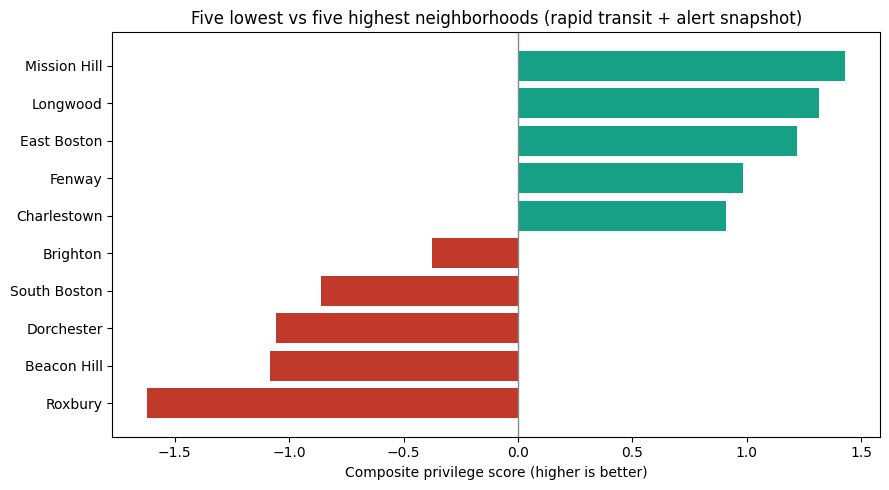

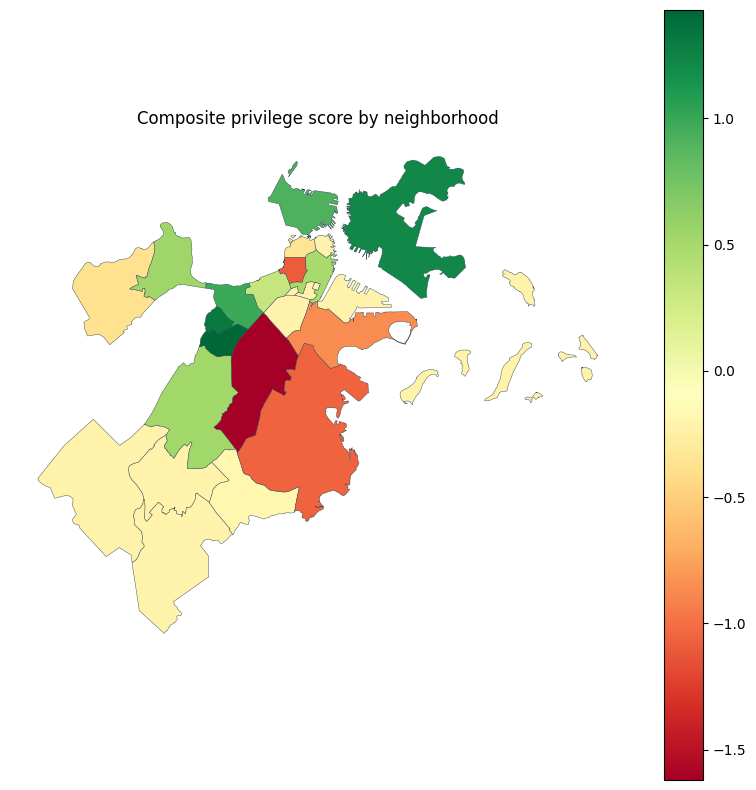

In [9]:
plot_df = ranked.sort_values("privilege_z")
bottom5 = plot_df.head(5)
top5 = plot_df.tail(5)
stacked = pd.concat([bottom5, top5])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(stacked["neighborhood"], stacked["privilege_z"], color=["#c0392b"] * 5 + ["#16a085"] * 5)
ax.axvline(0, color="#7f8c8d", linewidth=1)
ax.set_xlabel("Composite privilege score (higher is better)")
ax.set_title("Five lowest vs five highest neighborhoods (rapid transit + alert snapshot)")
fig.tight_layout()

map_df = nb.merge(ranked[["neighborhood", "privilege_z"]], on="neighborhood", how="left")
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8))
map_df.plot(column="privilege_z", legend=True, ax=ax2, cmap="RdYlGn", edgecolor="#2c3e50", linewidth=0.3)
ax2.set_axis_off()
ax2.set_title("Composite privilege score by neighborhood")
fig2.tight_layout()
plt.show()

## 8) Stress-test the weights (interactive in marimo)

Two sliders change how much **live alerts** (`zd`) and **chronic Blue Book pain** (`zb`) discount the access term (`za`). Drag them in marimo to see the ranking move; in Jupyter the cell falls back to defaults (`1.0`, `0.5`) and just renders a static chart.


In [10]:
try:
    import marimo as mo
    w_alerts  = mo.ui.slider(0.0, 2.0, value=1.0, step=0.1, label="Weight: live alerts")
    w_chronic = mo.ui.slider(0.0, 2.0, value=0.5, step=0.1, label="Weight: chronic pain")
    _controls = mo.hstack([w_alerts, w_chronic])
except Exception:
    class _Stub:
        def __init__(self, v):
            self.value = v
    w_alerts = _Stub(1.0)
    w_chronic = _Stub(0.5)
    _controls = "Sliders only render in marimo; using defaults (alerts=1.0, chronic=0.5)."
_controls


_FlexContainerHtml()

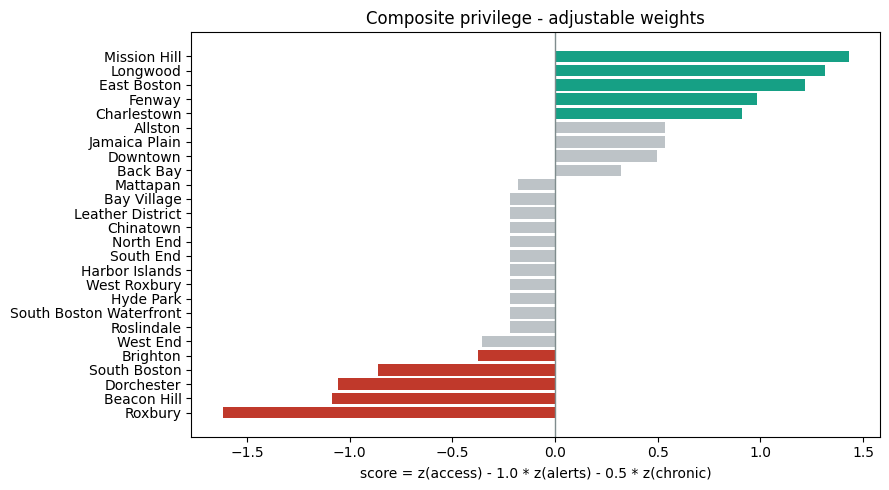

In [11]:
za_ = (base["log_access"] - base["log_access"].mean()) / (base["log_access"].std(ddof=0) + 1e-9)
zd_ = (base["alert_severity_sum"] - base["alert_severity_sum"].mean()) / (base["alert_severity_sum"].std(ddof=0) + 1e-9)
zb_ = (base["chronic_pain"] - base["chronic_pain"].mean()) / (base["chronic_pain"].std(ddof=0) + 1e-9)

score_live = za_ - w_alerts.value * zd_ - w_chronic.value * zb_
view_live = base.assign(score=score_live).sort_values("score")

fig_w, ax_w = plt.subplots(figsize=(9, 5))
n_view = len(view_live)
colors_w = ["#c0392b"] * 5 + ["#bdc3c7"] * max(n_view - 10, 0) + ["#16a085"] * 5
ax_w.barh(view_live["neighborhood"], view_live["score"], color=colors_w[:n_view])
ax_w.axvline(0, color="#7f8c8d", lw=1)
ax_w.set_xlabel(
    f"score = z(access) - {w_alerts.value:.1f} * z(alerts) - {w_chronic.value:.1f} * z(chronic)"
)
ax_w.set_title("Composite privilege - adjustable weights")
fig_w.tight_layout()
plt.show()


---

**Takeaway:** this notebook combines **rapid-transit proximity**, **live MBTA alert exposure**, and **MassDOT Blue Book route-level ratios** (chronic “pain”) into one rerunnable sketch. Treat the map as a conversation starter: validate with rider experience, census commute data, and any newer official dashboards you prefer.
